In [48]:
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, confusion_matrix
)
import tensorflow as tf
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


In [49]:
import os

dataset_base_dir = "./data"


normal_dir = os.path.join(dataset_base_dir, 'NORMAL')
pneumonia_dir = os.path.join(dataset_base_dir, 'PNEUMONIA')

# # Total counts
total_normal = len(os.listdir(normal_dir))
total_pneumonia = len(os.listdir(pneumonia_dir))

print(total_normal)
print(total_pneumonia)

1584
4273


In [50]:
import os
import pandas as pd

# Path to your dataset
classes = ['NORMAL', 'Pneumonia']

data = []
for label in classes:
    class_dir = os.path.join(dataset_base_dir, label)
    for fname in os.listdir(class_dir):
        if fname.endswith(".jpeg"):
            data.append({
                "path": os.path.join(class_dir, fname),
                "label": label
            })

df = pd.DataFrame(data)

In [51]:
model_paths = [
    "best_vgg16_aco_model.keras",
    "best_vgg16_bayes_model.keras",
    "best_vgg16_gwo_model.keras",
    "best_vgg16_model_deap.keras",
    "best_vgg16_modelGA.keras",
    "best_vgg16_pso_model.keras"
]

models = [load_model("Models/" + path) for path in model_paths]
print(f"{len(models)} base models loaded.")


6 base models loaded.


In [52]:
def get_stacking_features(models, X):
    meta_features = []

    for model in models:
        preds = model.predict(X, verbose=0)

        # Binary: shape (N, 1) → flatten
        if preds.shape[1] == 1:
            preds = preds.flatten().reshape(-1, 1)

        meta_features.append(preds)

    return np.hstack(meta_features)


In [53]:
def build_meta_learner(input_dim, num_classes=2):
    model = Sequential()
    model.add(Dense(32, activation="relu", input_shape=(input_dim,)))
    model.add(Dropout(0.3))
    model.add(Dense(16, activation="relu"))
    model.add(Dropout(0.2))

    if num_classes == 2:
        model.add(Dense(1, activation="sigmoid"))
        loss = "binary_crossentropy"
    else:
        model.add(Dense(num_classes, activation="softmax"))
        loss = "categorical_crossentropy"

    model.compile(optimizer=Adam(0.001), loss=loss, metrics=["accuracy"])
    return model


In [54]:
from sklearn.model_selection import train_test_split

# Train/Val/Test split (70/15/15)
train_val_df, test_df = train_test_split(
    df, 
    test_size=0.15, 
    stratify=df['label'], 
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.176,   # 0.176 of remaining 85% ≈ 15%
    stratify=train_val_df['label'],
    random_state=42
)

print(train_df.shape, val_df.shape, test_df.shape)


(4101, 2) (876, 2) (879, 2)


In [55]:
def load_images(paths):
    imgs = []
    for p in paths:
        img = tf.keras.preprocessing.image.load_img(p, target_size=(150,150))
        img = tf.keras.preprocessing.image.img_to_array(img)
        img = img / 255.0
        imgs.append(img)
    return np.array(imgs)


In [56]:
print(df.columns)
df.head()


Index(['path', 'label'], dtype='object')


,path,label
0,./data\NORMAL\IM-0001-0001.jpeg,NORMAL
1,./data\NORMAL\IM-0003-0001.jpeg,NORMAL
2,./data\NORMAL\IM-0005-0001.jpeg,NORMAL
3,./data\NORMAL\IM-0006-0001.jpeg,NORMAL
4,./data\NORMAL\IM-0007-0001.jpeg,NORMAL


In [57]:
X_train = load_images(train_df['path'].values)
X_val   = load_images(val_df['path'].values)
X_test  = load_images(test_df['path'].values)

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values


In [58]:
print("Extracting meta-features...")

train_meta = get_stacking_features(models, X_train)
val_meta   = get_stacking_features(models, X_val)
test_meta  = get_stacking_features(models, X_test)

input_dim = train_meta.shape[1]
print("Meta-feature size:", input_dim)


Extracting meta-features...
Meta-feature size: 6


In [60]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val   = le.transform(y_val)
y_test  = le.transform(y_test)

print(le.classes_)  # should show ['NORMAL' 'PNEUMONIA']


['NORMAL' 'Pneumonia']


In [62]:
start_time = time.time()

meta_model = build_meta_learner(input_dim, num_classes=2)

history = meta_model.fit(
    train_meta, y_train,
    epochs=20,
    batch_size=16,
    validation_data=(val_meta, y_val),
    verbose=1
)

end_time = time.time()
execution_time = end_time - start_time
print(f"Training time: {execution_time:.2f} seconds")


Epoch 1/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8195 - loss: 0.3978 - val_accuracy: 0.9840 - val_loss: 0.0582
Epoch 2/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9811 - loss: 0.0791 - val_accuracy: 0.9852 - val_loss: 0.0501
Epoch 3/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9784 - loss: 0.0858 - val_accuracy: 0.9852 - val_loss: 0.0481
Epoch 4/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9798 - loss: 0.0806 - val_accuracy: 0.9840 - val_loss: 0.0481
Epoch 5/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0776 - val_accuracy: 0.9852 - val_loss: 0.0502
Epoch 6/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9846 - loss: 0.0597 - val_accuracy: 0.9863 - val_loss: 0.0464
Epoch 7/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9832 - loss: 0.0641 - val_accuracy: 0.9863 - val_loss: 0.0467
Epoch 8/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9855 - loss: 0.0647 - val_accuracy: 0.

In [63]:
import joblib
joblib.dump(meta_model, "stacking_meta_model.pkl")


['stacking_meta_model.pkl']

In [64]:
y_pred_prob = meta_model.predict(test_meta).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)


28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [65]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("Time until output:", execution_time, "seconds")


Accuracy: 0.9761092150170648
Precision: 0.984375
Recall: 0.982839313572543
F1 Score: 0.9836065573770492
Time until output: 10.750574350357056 seconds


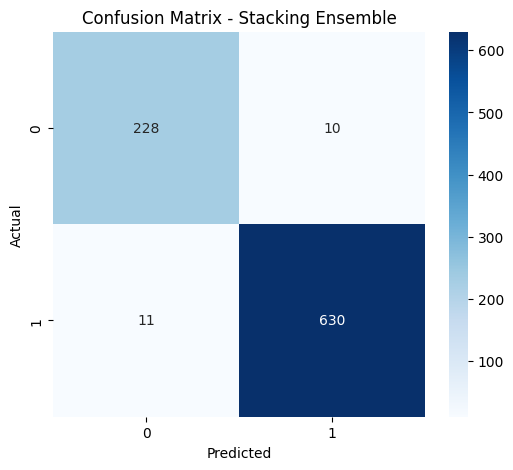

In [66]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Stacking Ensemble")
plt.show()


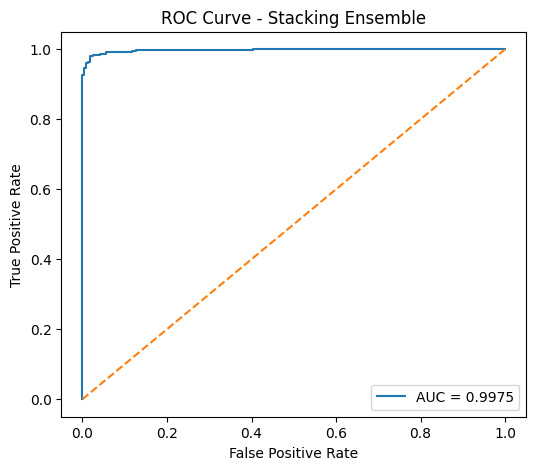

AUC Score: 0.9974698147589769


In [67]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Ensemble")
plt.legend()
plt.show()

print("AUC Score:", auc)


In [69]:
#  load the meta-model
meta_model = joblib.load("stacking_meta_model.pkl")

# test a single image
test_image_path = test_df['path'].values[0]
img = tf.keras.preprocessing.image.load_img(test_image_path, target_size=(150,150))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)  # shape (1,150, 150, 3)
meta_features = get_stacking_features(models, img_array)
prediction_prob = meta_model.predict(meta_features).flatten()[0]
prediction = (prediction_prob >= 0.5).astype(int)
print("Predicted class:", le.inverse_transform([prediction])[0])
print("Prediction probability:", prediction_prob)
print("Actual class:", test_df['label'].values[0])
def get_stacking_features(models, X):
    meta_features = []
    for model in models:
        preds = model.predict(X, verbose=0)
 
        # Binary: shape (N, 1) → flatten
        if preds.shape[1] == 1:
            preds = preds.flatten().reshape(-1, 1)
 
        meta_features.append(preds)
    # Stack: shape → (num_samples, num_models * num_classes)
    return np.hstack(meta_features)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted class: NORMAL
Prediction probability: 0.0062556844
Actual class: NORMAL
